In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from xgboost import XGBRegressor

In [2]:
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

# Remove outliers
df = df[df['AveRooms'] < df['AveRooms'].quantile(0.99)]
df = df[df['AveBedrms'] < df['AveBedrms'].quantile(0.99)]
df = df[df['Population'] < df['Population'].quantile(0.99)]
df = df[df['AveOccup'] < df['AveOccup'].quantile(0.99)]

# Split
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
scaler = joblib.load('../model/scaler.pkl')
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Load saved model
model = joblib.load('../model/house_price_model.pkl')

# Get predictions
y_pred = model.predict(X_test_scaled)

print("Model and data loaded.")
print(f"Test samples: {len(y_test)}")

Model and data loaded.
Test samples: 3965


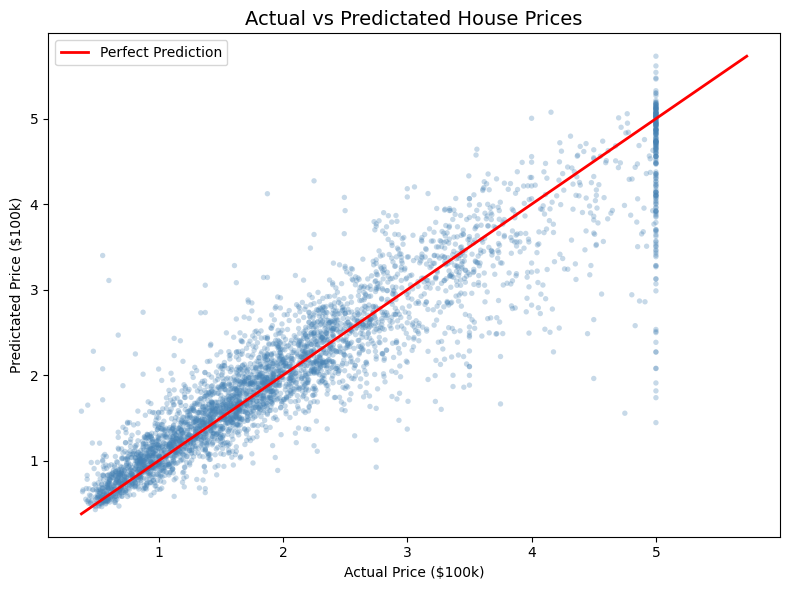

In [3]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color = 'steelblue', edgecolors= 'none', s = 15)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color = 'red', linewidth = 2, label = 'Perfect Prediction')

plt.title("Actual vs Predictated House Prices", fontsize = 14)
plt.xlabel("Actual Price ($100k)")
plt.ylabel("Predictated Price ($100k)")
plt.legend()
plt.tight_layout()
plt.show()

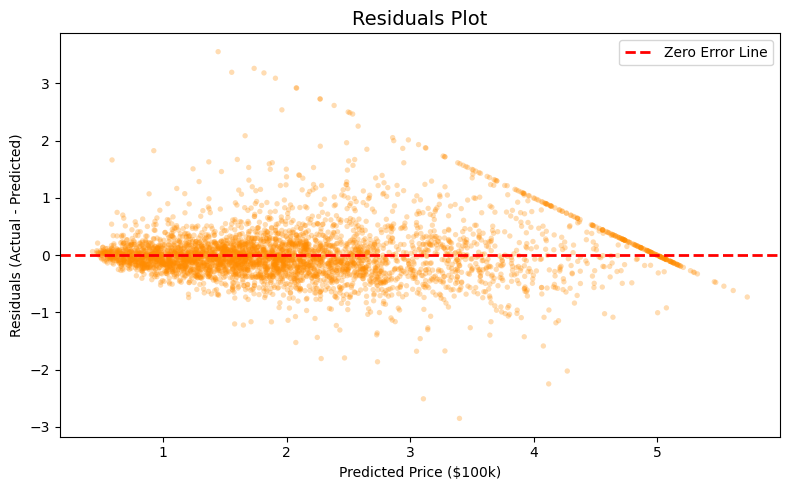

In [4]:
residuals = y_test - y_pred
plt.figure(figsize = (8, 5))
plt.scatter(y_pred, residuals, alpha= 0.3, color = 'darkorange', edgecolors= 'none', s = 15 )
plt.axhline(y = 0, color = 'red', linewidth = 2, linestyle = '--', label = 'Zero Error Line')

plt.title("Residuals Plot", fontsize = 14)
plt.xlabel("Predicted Price ($100k)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.legend()
plt.tight_layout()
plt.show()

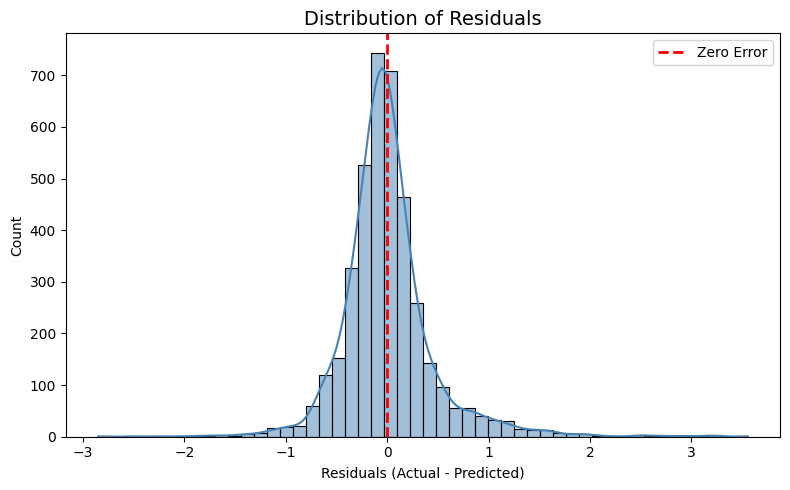

In [5]:
plt.figure(figsize=(8, 5))

sns.histplot(residuals, bins=50, kde=True, color='steelblue')
plt.axvline(x=0, color = 'red', linewidth = 2, linestyle = '--', label = 'Zero Error')

plt.title("Distribution of Residuals", fontsize = 14)
plt.xlabel("Residuals (Actual - Predicted)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

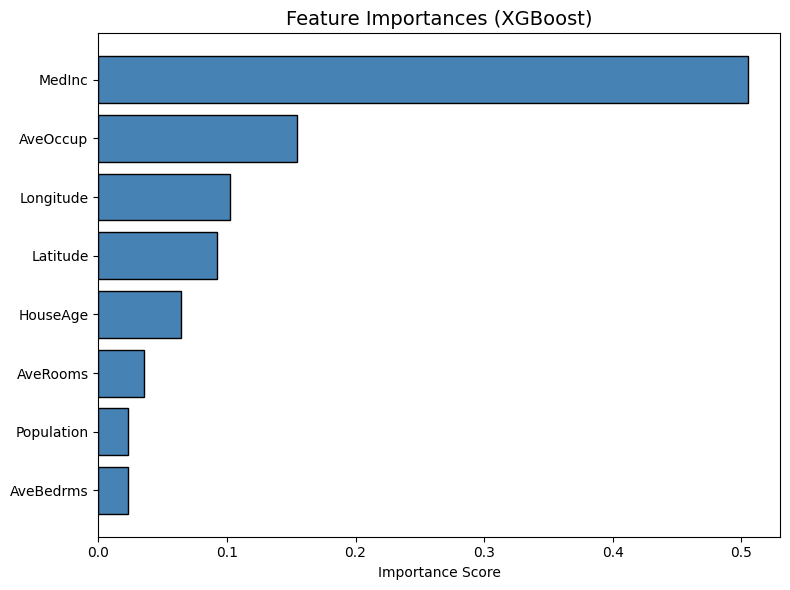

In [6]:
importances = model.feature_importances_
feature_names = X.columns

feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances 
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(feat_df['Feature'], feat_df['Importance'], color = 'steelblue', edgecolor = 'black')
plt.title("Feature Importances (XGBoost)", fontsize = 14)
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [8]:
train_pred = model.predict(X_train_scaled)
test_pred = model.predict(X_test_scaled)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print("====== Overfitting Check ======")
print(f"Train R² : {train_r2:.4f}")
print(f"Test R² : {test_r2:.4f}")
print(f"Difference: {train_r2 - test_r2:.4f}")

if train_r2 - test_r2 < 0.05:
    print("\n Model is NOT overfitting -- gap is small.")
elif train_r2 - test_r2 < 0.10:
    print("\n Slight overfitting -- acceptable for this project ")
else:
    print("\n Model is overfitting -- needs regularization.")        

====== Overfitting Check ======
Train R² : 0.9325
Test R² : 0.8480
Difference: 0.0845

 Slight overfitting -- acceptable for this project 


In [12]:
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("===================================")
print("       Final Model Performance    ")
print("===================================")
print(f"  MAE    :   {mae:.4f}    (${mae*100000:.0f} avg error)")
print(f"  RMSE   :   {rmse:.4f}")
print(f"  R²     :   {r2:.4f}")
print("===================================")


       Final Model Performance    
  MAE    :   0.2988    ($29876 avg error)
  RMSE   :   0.4583
  R²     :   0.8480
